<a href="https://colab.research.google.com/github/Rahul190296/Aerofit-customer-analysis/blob/main/Aerofit_case_study_New_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Business Case Study - Aerofit**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Aerofit.csv to Aerofit.csv


# **Imported the data into colab book**

In [ ]:
df = pd.read_csv('/content/Aerofit.csv')
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


# **Aerofit dataset information**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


Aerofit data consist of 180 product purchase data of differnt customers
data set has 180 rows and 11 columns

Added below Colmns for analysis Purpose


1.   Product_tier
2.   price
3.   Age_group bin

In [ ]:
df['Product_Tier'] = df['Product'].map({
    'KP281': 'Entry',
    'KP481': 'Mid',
    'KP781': 'Premium'
})

In [ ]:
df['Price'] = df['Product'].map({
    'KP281': 1500,
    'KP481': 1750,
    'KP781': 2500
})

In [ ]:
df['Age_group'] = pd.cut(df['Age'], bins=[17,25,35,40,60] , labels=['17-25','26-35','36-40','41-60'])

In [ ]:
df['Usage_Level'] = pd.cut(df['Usage'],
                           bins=[0,2,4,7],
                           labels=['Low','Medium','High'])

In [ ]:
df['Fitness_Level'] = pd.cut(
    df['Fitness'],
    bins=[0,2,3,5],
    labels=['Low','Medium','High'],
    include_lowest=True
)

In [ ]:
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Product_Tier,Price,Age_group,Usage_Level,Fitness_Level
0,KP281,18,Male,14,Single,3,4,29562,112,Entry,1500,17-25,Medium,High
1,KP281,19,Male,15,Single,2,3,31836,75,Entry,1500,17-25,Low,Medium
2,KP281,19,Female,14,Partnered,4,3,30699,66,Entry,1500,17-25,Medium,Medium
3,KP281,19,Male,12,Single,3,3,32973,85,Entry,1500,17-25,Medium,Medium
4,KP281,20,Male,13,Partnered,4,2,35247,47,Entry,1500,17-25,Medium,Low


In [ ]:
df['Product'].value_counts()

,count
Product,
KP281,80
KP481,60
KP781,40


In [ ]:
df['Age_group'].value_counts()

,count
Age_group,
17-25,79
26-35,73
36-40,16
41-60,12


In [ ]:
df['Product'].unique()

array(['KP281', 'KP481', 'KP781'], dtype=object)

In [ ]:
df['Product_Tier'].unique()

array(['Entry', 'Mid', 'Premium'], dtype=object)

In [ ]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

# **Cleaning data**


Decimal values in Age , Useage and Income rounding the value to Complete int
   



In [ ]:
df['Income'] = df['Income'].round().astype(int)

# **Fig Analysis : Univeriate and Biveriate analysis**

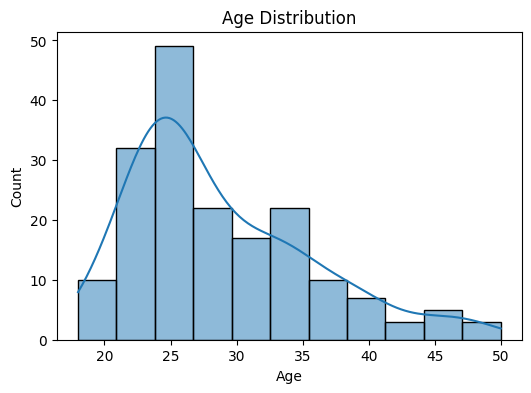

In [ ]:
#Age group distibution

plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

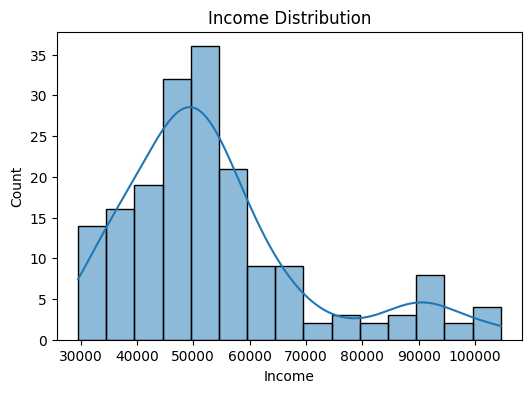

In [ ]:
#Income distribution

plt.figure(figsize=(6,4))
sns.histplot(df['Income'], kde=True)
plt.title("Income Distribution")
plt.show()

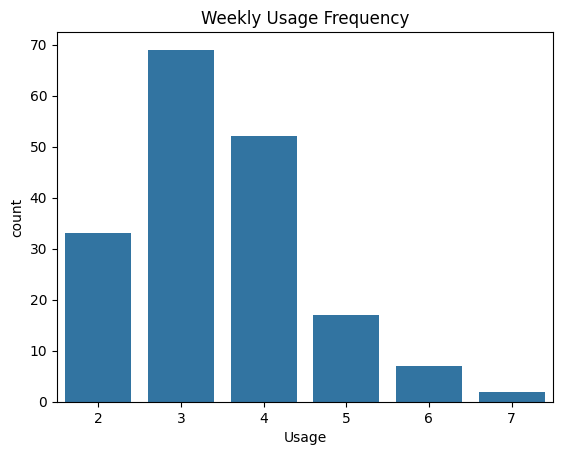

In [ ]:
sns.countplot(x='Usage', data=df)
plt.title("Weekly Usage Frequency")
plt.show()

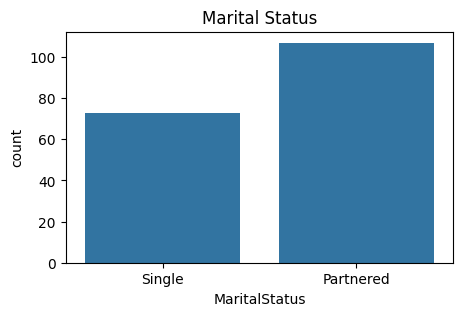

In [ ]:
plt.figure(figsize=(5,3))
sns.countplot(x='MaritalStatus', data=df)
plt.title("Marital Status")
plt.show()

Below figer shows that those who have higher income buy premium product range

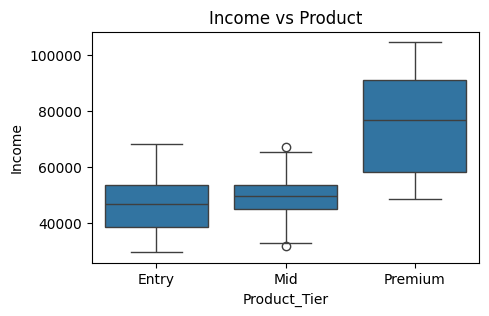

In [ ]:
plt.figure(figsize=(5,3))
sns.boxplot(x='Product_Tier', y='Income', data=df)
plt.title("Income vs Product")
plt.show()

# **Defining Outliers amoung columns**

In [ ]:
continuous_cols = ['Age','Income','Usage','Fitness','Miles','Price']

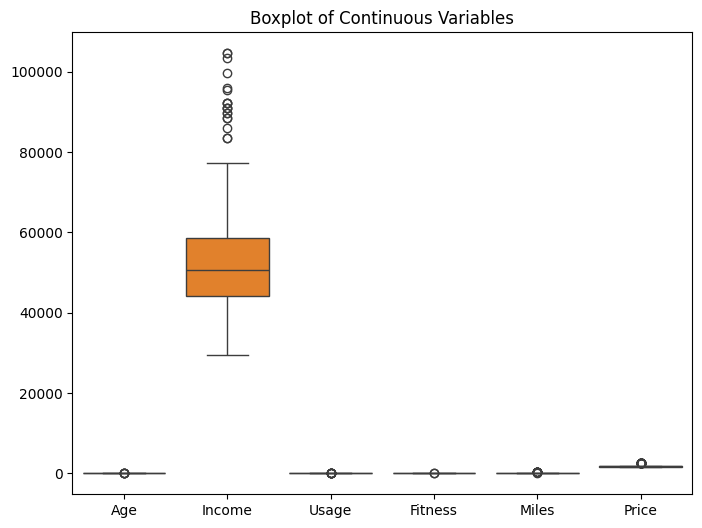

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df[continuous_cols])
plt.title("Boxplot of Continuous Variables")
plt.show()

In [ ]:
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Age: 5 outliers
Income: 19 outliers
Usage: 9 outliers
Fitness: 2 outliers
Miles: 13 outliers
Price: 40 outliers


# **Removing Outliers below 5% and above 95%**

In [ ]:
lower = df['Income'].quantile(0.05)
upper = df['Income'].quantile(0.95)

In [ ]:
for col in continuous_cols:
    lower = df[col].quantile(0.05)
    upper = df[col].quantile(0.95)
    df[col] = np.clip(df[col], lower, upper)

In [ ]:
df['Price'].max()

2500

# **Finding Relation between Categorical column and output**

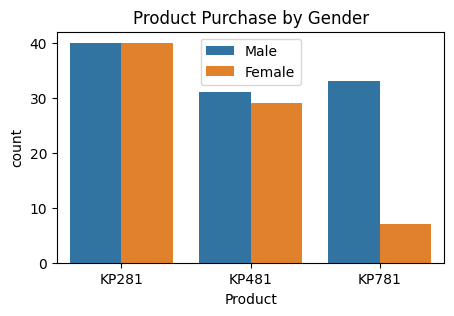

In [ ]:
#Gender vs Product
plt.figure(figsize=(5,3))
sns.countplot(x='Product', hue='Gender', data=df )
plt.title("Product Purchase by Gender")
plt.legend()
plt.show()


In [ ]:
df.columns

Index(['Product', 'Age', 'Gender', 'Education', 'MaritalStatus', 'Usage',
       'Fitness', 'Income', 'Miles', 'Product_Tier', 'Price', 'Age_group',
       'Usage_Level', 'Fitness_Level'],
      dtype='object')

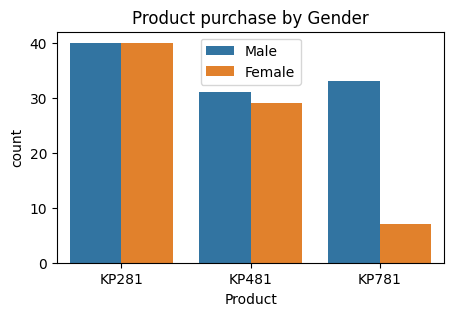

In [ ]:
plt.figure(figsize=(5,3))
sns.countplot(x= 'Product' , hue = 'Gender' , data = df)
plt.title("Product purchase by Gender")
plt.legend()
plt.show()

In [ ]:
pd.crosstab(df['Gender'], df['Product'], normalize='index') * 100

Product,KP281,KP481,KP781
Gender,,,
Female,52.631579,38.157895,9.210526
Male,38.461538,29.807692,31.730769


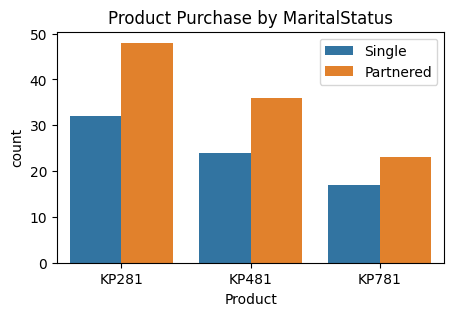

In [ ]:
#Gender vs Product
plt.figure(figsize=(5,3))
sns.countplot(x='Product', hue='MaritalStatus',  data = df )
plt.title("Product Purchase by MaritalStatus")
plt.legend()
plt.show()


Below figure shows which age group buy which product

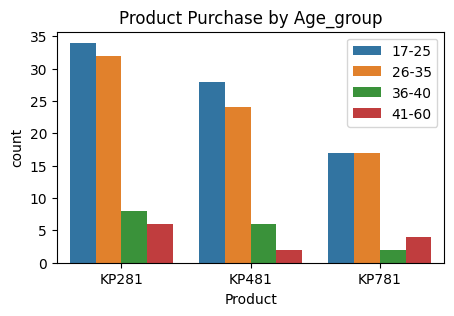

In [ ]:
plt.figure(figsize=(5,3))
sns.countplot(x='Product' , hue = 'Age_group' , data = df)
plt.title("Product Purchase by Age_group")
plt.legend()
plt.show()

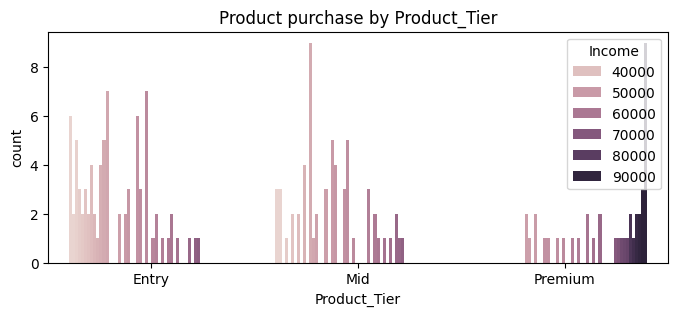

In [ ]:
plt.figure(figsize=(8,3))
sns.countplot(x ='Product_Tier' , hue= 'Income' , data = df)
plt.title("Product purchase by Product_Tier")
plt.show()

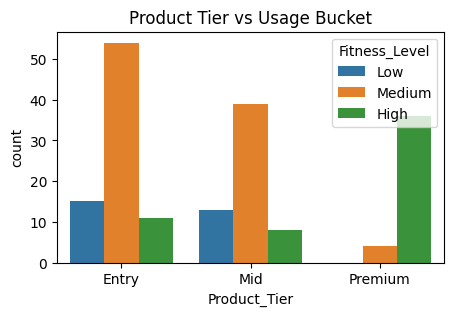

In [ ]:
plt.figure(figsize=(5,3))
sns.countplot(
    data=df,
    x='Product_Tier',
    hue='Fitness_Level'
)
plt.title("Product Tier vs Usage Bucket")
plt.show()

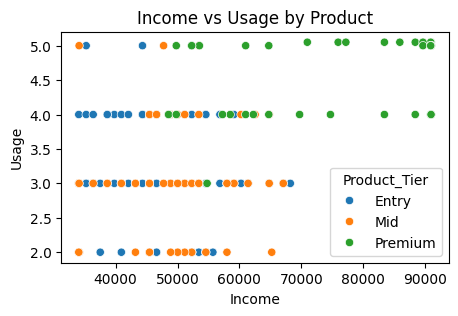

In [ ]:
plt.figure(figsize=(5,3))
sns.scatterplot(x='Income', y='Usage',
                hue='Product_Tier',
                data=df)
plt.title("Income vs Usage by Product")
plt.show()

**From the above analysis we observed that**


1.   Male Customers prefer buy Premium product  
2.   Younger age group prefer entry level product
3.   Partnered section slightly buy mid to premium level product
4.   Customers with higher fitness level and weekly usage by premium products






In [ ]:
df.to_csv('Aerofit.csv', index=False)

from google.colab import files
files.download('Aerofit.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Representation of probability**

In [ ]:
#Overall marginal Probability for customer to purchase product

marginal = (pd.crosstab(df['Product'] , columns= 'Probability' , normalize= True)*100).reset_index()

marginal.columns = ['Product' , 'Probability' ]

marginal

,Product,Probability
0,KP281,44.444444
1,KP481,33.333333
2,KP781,22.222222


In [ ]:
marginal_G = pd.crosstab(df['Gender'],df['Product'] ,normalize='index') * 100

marginal_G.columns.name = None

marginal_G.index.name = None

marginal_G = marginal_G.reset_index()

marginal_G

,index,KP281,KP481,KP781
0,Female,52.631579,38.157895,9.210526
1,Male,38.461538,29.807692,31.730769


**Findings**



1.   Overall marginal probability shows the KP281 has the higthes probability to be purchased amoung all customers
2.   Male customers has high probability to purchase KP281 (39%) which is mostly by low to mid income male customers followed by KP781 (31%) which is populer amount high income male customers  
3.   Female customers has high probability to purchase KP281 (52%) Followed by KP481 (38%)







# **Correlation**

In [ ]:
numeric_cols = ['Age','Education','Usage','Fitness','Income','Miles','Price'  ]


numeric_df = df.select_dtypes(include='number')

In [ ]:
corr_matrix = numeric_df.corr()
corr_matrix

,Age,Education,Usage,Fitness,Income,Miles,Price
Age,1.000000,0.279533,0.015394,0.057361,0.514362,0.029636,0.022110
Education,0.279533,1.000000,0.388802,0.430480,0.628908,0.367262,0.563463
Usage,0.015394,0.388802,1.000000,0.661978,0.481608,0.771030,0.598803
Fitness,0.057361,0.430480,0.661978,1.000000,0.546998,0.826307,0.706978
Income,0.514362,0.628908,0.481608,0.546998,1.000000,0.537297,0.699111
Miles,0.029636,0.367262,0.771030,0.826307,0.537297,1.000000,0.665304
Price,0.022110,0.563463,0.598803,0.706978,0.699111,0.665304,1.000000


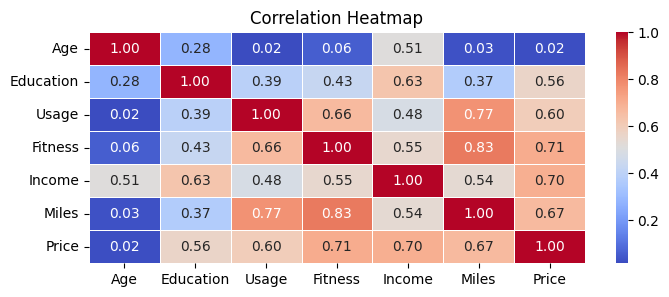

In [ ]:
plt.figure(figsize=(8,3 ))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# **Finding and correlations**


1.Fitness and Miles (0.79), as well as Usage and Miles (0.76), show strong positive correlations. This indicates that customers with higher fitness levels and more frequent usage tend to cover more miles on the treadmill.

2.Income and Price (0.70) have a strong positive correlation, suggesting that higher-income customers are more likely to purchase higher-priced (premium) treadmill models.

3.Fitness and Price (0.70) show a strong positive relationship. This indicates that highly fitness-oriented customers tend to prefer premium treadmill models.

4.Education and Income (0.63) have a moderate positive correlation, suggesting that higher educational qualifications are associated with higher income levels.

5.Education and Income (0.63) have a moderate positive correlation, suggesting that higher educational qualifications are associated with higher income levels.







